# Operatii pe vecinatate; filtrarea vectoriala a imaginilor
Imaginile color sunt matrice multi-dimensionale. Din acest motiv exista mai multe modalitati de a le prelucra, dintre care amintim:
 - Abordarea marginala, care presupune efectuarea operatiei de filtrare pe fiecare plan de culoare, independent;
 - Abordarea vectoriala, in care se tine cont ca fiecare pixel este format dintr-un vector (ex. triplet <font color=red>R</font><font color=green>G</font><font color=blue>B</font>).
 
Pentru laboratorul de astazi se va utiliza filtrare vectoriala bazata pe ordonare redusa, aplicata pe filtrul median. Ordonarea redusa presupune ca fiecarui vector sa i se asocieze un scalar obtinut pe baza componentelor vectorului. Scalarii sunt ordonati conform ordinii uzuale in $I\!R$. Ordinea scalarilor induce ordinea vectorilor.
$$X_i = [x_1,x_2,x_3] \rightarrow s_i \epsilon I\!R$$

O modalitate uzuala de obtinere a acestor scalari este <b>calculul de distante</b>.

## 1. Abordarea "distanta"
Scalarii calculati sunt distantele de la fiecare vector din vecinatate pana la un punct fix stabilit.
$$s_i = dist(X_i,X_{fix})$$

Puncte fixe:
 - Medianul marginal;
 - Media marginala.

In acest caz, medianul vectorial este vectorul cel mai apropiat de medianul marginal.<br>
<b>Exemplu:</b><br>
Alegem o vecinatate oarecare dintr-o imagine afectata de zgomot impulsiv.
Calculam medianul marginal, si distanta euclidiana intre fiecare triplet RGB din vecinatate si medianul marginal. Valoarea de iesire a filtrului este tripletul care a avut distanta cea mai mica.

<img src="abordare_distanta.png"><center>Exemplu de utilizare a abordarii distanta</center>

Vom refolosi din laboratorul trecut functiile de adaugare de zgomot pe imagini color si masurarea calitatii prin MSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

def add_Gaussian_noise(img,disp):
    if (np.max(img)>1):
        img = img/255.0
    zg = np.random.normal(0,disp,np.shape(img))
    imgzg = np.clip(img+zg,a_min=0,a_max=1)
    return imgzg

def add_impulsive_noise(img,p0,p1):
    if (np.max(img)>1):
        img = img/255.0
    [L,C,pl]=np.shape(img)
    Nrpix0 = int(L*C*p0)
    Nrpix1 = int(L*C*p1)
    
    for plan_curent in range(0,pl):
        numere_intregiL = np.random.randint(0,L,[Nrpix0])
        numere_intregiC = np.random.randint(0,C,[Nrpix0])
        img[numere_intregiL,numere_intregiC,plan_curent]=0
        numere_intregiL = np.random.randint(0,L,[Nrpix1])
        numere_intregiC = np.random.randint(0,C,[Nrpix1])
        img[numere_intregiL,numere_intregiC,plan_curent]=1
    
    return img

def mse(img0,img):
    if (np.max(img)>1):
        img = img/255.0
    if (np.max(img0)>1):
        img0 = img0/255.0
    MSE=np.sum((img-img0)**2)/np.prod(np.shape(img))
    
    sumval=np.sum(img0**2)/np.prod(np.shape(img))
    NMSE = MSE/sumval
    
    return MSE, NMSE

Nu uitati de metoda de bordare rapida a unei imagini scalare:
```from scipy import signal
kernel=np.zeros((2*W+1,2*W+1))
kernel[W,W]=1
Ybordat = signal.convolve2d(Y, kernel, mode='full', boundary='symm')```

### Medianul marginal - (ar fi trebuit facut in laboratorul anterior)
### Exercitiul 5. Folosind functia definita la ex.2 si o imagine la alegere, creeati o imagine afectata de zgomot impulsiv. Utilizati filtrul median <i>marginal</i> pentru reducerea zgomotului. Cum arata imaginea de iesire? Incercati sa utilizati filtrul median marginal si pentru zgomot Gaussian. Masurati calitatea cu functia definita la ex.3.
Pentru a sorta crescator o matrice puteti folosi functia ```np.sort()```:
```vector_sortat = np.sort(vector)```
Daca aveti de-a face cu o matrice insa, functia ```np.sort()``` va sorta fiecare linie individual. Pentru a solutiona aceasta problema, aveti doua solutii:
 - Transformati mai intai matricea in vector cu ```vector = matrice.flatten()```;
 - Mentionati ca nu vreti de-a lungul vreunei axe anume sortarea ```vector = np.sort(matrice,axis=None)```

(<Figure size 640x480 with 1 Axes>,
 [])

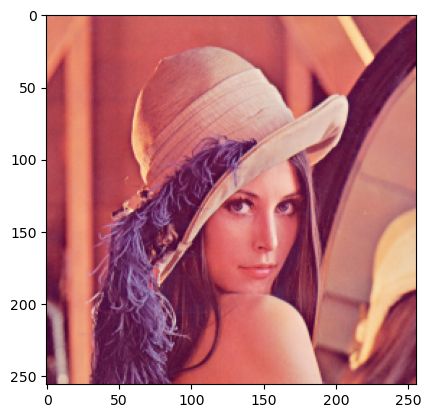

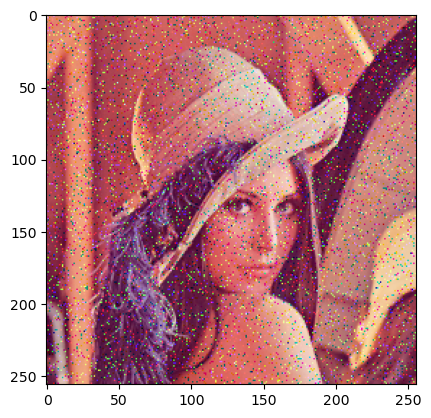

In [3]:
img = io.imread('lenamic.png')
plt.figure(), plt.imshow(img), plt.plot()
img = img[:,:,0:3]
# print(np.shape(img))
imgzg = add_impulsive_noise(img,0.03,0.03)
plt.figure(), plt.imshow(imgzg), plt.plot()

In [27]:
from scipy import signal

def median_scalar(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C] = np.shape(img)
    kernel = np.zeros((dim, dim))
    poz_median = dim*dim//2
    W = dim//2
    kernel[W,W] = 1
    Ybordat = signal.convolve2d(img, kernel, mode='full', boundary = 'symm')
    imgout = np.zeros((L,C))
    for l in range (0, L):
        for c in range (0, C):
            #selecteaza valori conform ferestri plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W, c-W+W:c+W+1+W]
            #combina valorile selectate
            val_sortate = np.sort(np.ndarray.flatten(val_selectate))
            #scrie rezultatul in imgout[l,c]
            imgout[l,c]=val_sortate[poz_median]
    return imgout

In [29]:
def median_marginal(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C,pl] = np.shape(img)
    imgout = np.zeros((L,C,pl))
    for p in range (0, pl):
        imgout[:,:,p] = median_scalar(img[:,:,p], dim)

    return imgout
    

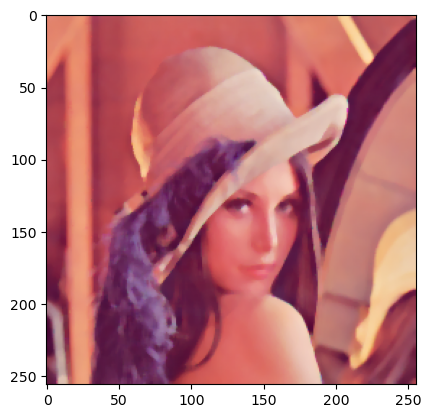

(<Figure size 640x480 with 1 Axes>,
 None)

In [33]:
imgrez_mm = median_marginal(imgzg, 5)
plt.figure(), plt.imshow(imgrez_mm), plt.show()

In [65]:
#EXERCITIUL 1 IMPLEMENTATI FILTRUL MEDIAN VECTORIAL OBTINUT PRIN ABORDAREA DISTANTA 

#median vectorial bazat pe distanta la medianul marginal local

def median_vectorial_dist_la_mm(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C,pl] = np.shape(img)
    kernel = np.zeros((dim, dim))
    poz_median = dim*dim//2
    W = dim//2
    kernel[W,W] = 1
    Ybordat = np.zeros((L+dim-1, C+dim-1, pl))
    for p in range (0,pl):
        Ybordat[:, :, p] = signal.convolve2d(img[:,:,p], kernel, mode='full', boundary = 'symm')

    MM = median_marginal(img, dim)

    #TEMA: schimbare median_marginal in media aritmetica ca punct de referinta + de facut diferenta
    imgout = np.zeros((L,C,pl))
    for l in range (0, L):
        for c in range (0, C):
            #selecteaza valori conform ferestri plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W, c-W+W:c+W+1+W, :]
            #combina valorile selectate
            
            #calculez distanta de la fiecare culoare din val_selectate 
            #la medianul marginal local din MM[l,c, :]
            dist = np.sum((val_selectate - MM[l,c,:])**2, axis=2)  
            #aflam pe care pozitie din vecinatate se gaseste distanta minima
            pos = np.argmin(dist)
            pos_linie = pos//dim
            pos_col = pos%dim
            #scrie rezultatul in imgout[l,c]
            imgout[l,c,:]=val_selectate[pos_linie, pos_col,:]
    return imgout

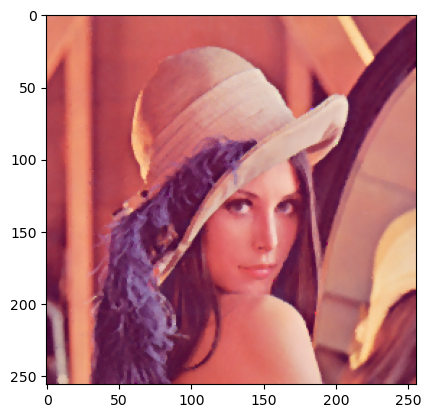

(<Figure size 640x480 with 1 Axes>,
 None)

In [67]:
imgrez_dist_mm = median_vectorial_dist_la_mm(imgzg, 3)
plt.figure(), plt.imshow(imgrez_dist_mm), plt.show()

## 2. Abordarea "distanta agregata"
In acest caz nu mai este nevoie de calculul unui punct fix. Scalarul se calculeaza ca suma distantelor de la fiecare vector pana la toti ceilalti:
$$ s_i = \sum_{j=1}^Ndist(X_i,X_j)$$
Vectorul castigator este cel care are distanta agregata minima.

### Exercitiul 2. Implementati un filtru median vectorial obtinut prin abordarea "distanta agregata".

In [71]:
def median_vectorial_dist_agregata(img, dim):
    if(np.max(img)>1):
        img = img/255.0
    [L,C,pl] = np.shape(img)
    kernel = np.zeros((dim, dim))
    poz_median = dim*dim//2
    W = dim//2
    kernel[W,W] = 1
    Ybordat = np.zeros((L+dim-1, C+dim-1, pl))
    for p in range (0,pl):
        Ybordat[:, :, p] = signal.convolve2d(img[:,:,p], kernel, mode='full', boundary = 'symm')

    MM = median_marginal(img, dim)

    #TEMA: schimbare median_marginal in media aritmetica ca punct de referinta + de facut diferenta
    imgout = np.zeros((L,C,pl))
    for l in range (0, L):
        for c in range (0, C):
            #selecteaza valori conform ferestri plasate (l,c)
            val_selectate = Ybordat[l-W+W:l+W+1+W, c-W+W:c+W+1+W, :]
            #combina valorile selectate
            
            #calculez distanta de la fiecare culoare din val_selectate 
            #la toate celelalte culori din val_selectate si sumez aceste distante
            dist = np.zeros((dim,dim))
            for i in range(0, dim):
                for j in range(0, dim):
                    vector_curent = val_selectate[i,j,:]
                    dist[i,j] = np.sum(np.sum(np.abs(val_selectate - vector_curent),axis=2))
            #aflam pe care pozitie din vecinatate se gaseste distanta minima
            pos = np.argmin(dist)
            pos_linie = pos//dim
            pos_col = pos%dim
            #scrie rezultatul in imgout[l,c]
            imgout[l,c,:]=val_selectate[pos_linie, pos_col,:]
    return imgout

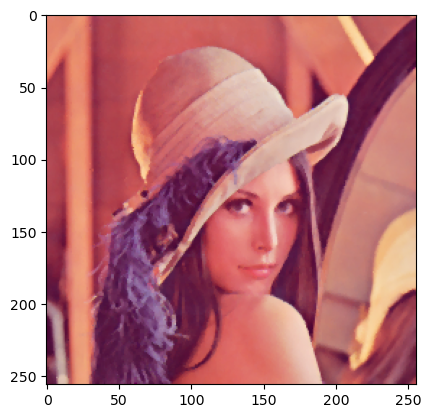

(<Figure size 640x480 with 1 Axes>,
 None)

In [73]:
imgrez_dist_agg = median_vectorial_dist_agregata(imgzg, 3)
plt.figure(), plt.imshow(imgrez_dist_agg), plt.show()

## 3. Abordarea "unghiulara"
Aceasta abordare presupune calcularea scalarilor ca distante unghiulare agregate, adica suma unghiurilor dintre vectorul curent si toti ceilalti vectori:
$$s_i = \sum_{j=1}^N\angle(X_i,X_j) = \sum_{j=1}^Narccos\left(\frac{<X_i,X_j>}{||X_i||\cdot||X_j||}\right)$$
Medianul vectorial este vectorul care are drept scalar cea mai mica distanta unghiulara agregata.

### Exercitiul 3. Implementati un filtru median vectorial obtinut prin abordarea "distanta unghiulara agregata".
Pentru calculul arccos, se poate folosi functia din numpy:
```python
x = np.arccos(x)
```

In [ ]:
# De facut, structura similara, necesitatea unei bucle for, similara cu Exercitiul 2 (partea cu i si j)